In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
from factor_analyzer.rotator import Rotator # Use a dedicated rotator library

# ===================================================================
# A) Configuration
# ===================================================================
MODEL_DIR = "../data" 
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

K_list = [1, 2, 3]
N_REPETITIONS = 100
ROTATION_METHOD = 'oblimin' # Or 'oblimin' if you prefer

print(f"Calculating standard errors for K={K_list} using a single '{ROTATION_METHOD}' rotation.")

# ===================================================================
# B) Main Calculation Loop
# ===================================================================
summary_results = []
for k in K_list:
    print(f"\n--- Processing K = {k} ---")
    
    # --- 1. Load all raw model parameters from each repetition ---
    theta_reps, a_reps, b_reps = [], [], []
    for r in range(N_REPETITIONS):
        model_path = os.path.join(MODEL_DIR, f"mirt_model_k{k}_rep{r}.pt")
        try:
            state = torch.load(model_path, map_location="cpu")
            theta_reps.append(state['theta'].numpy())
            a_reps.append(state['a'].numpy())
            b_reps.append(state['b'].numpy())
        except FileNotFoundError:
            continue
    
    if not theta_reps:
        print(f"❌ No model files found for K={k}. Skipping.")
        continue

    # Convert lists of arrays to 3D numpy arrays for easier processing
    theta_stack_raw = np.stack(theta_reps)
    a_stack_raw = np.stack(a_reps)
    b_stack_raw = np.stack(b_reps)

    # --- 2. Perform a single, singular rotation ---
    if k > 1:
        print(f"  Performing one singular '{ROTATION_METHOD}' rotation...")
        # Calculate the average of the un-rotated discrimination matrices
        a_mean_raw = a_stack_raw.mean(axis=0)

        # Initialize and fit the rotator on the stable, average matrix
        rotator = Rotator(method=ROTATION_METHOD)
        rotator.fit(a_mean_raw)
        
        # This is the single transformation matrix we will apply to all runs
        R = rotator.rotation_ # Shape: (k, k)
        
        # Apply the single rotation to all repetitions at once using broadcasting
        a_stack_rotated = np.einsum('nij,jk->nik', a_stack_raw, R)
        theta_stack_rotated = np.einsum('nij,jk->nik', theta_stack_raw, R)
    else:
        # No rotation needed for a single dimension
        a_stack_rotated = a_stack_raw
        theta_stack_rotated = theta_stack_raw

    # --- 3. Fix sign flips for consistency ---
    # After rotation, factors can still have flipped signs.
    # We force the average loading on each factor to be positive.
    for dim in range(k):
        if np.mean(a_stack_rotated[:, :, dim]) < 0:
            a_stack_rotated[:, :, dim] *= -1
            theta_stack_rotated[:, :, dim] *= -1

    # --- 4. Calculate Standard Errors on the aligned data ---
    theta_se = np.std(theta_stack_rotated, axis=0)
    a_se = np.std(a_stack_rotated, axis=0)
    b_se = np.std(b_stack_raw, axis=0) # 'b' is not affected by rotation

    # --- 5. Save results ---
    se_output_path = os.path.join(OUTPUT_DIR, f"standard_errors_k{k}.npz")
    np.savez_compressed(se_output_path, theta_se=theta_se, a_se=a_se, b_se=b_se)
    print(f"  ✅ Saved SE arrays to: {se_output_path}")

    summary_results.append({
        'K': k,
        'avg_theta_se': np.mean(theta_se),
        'avg_a_se': np.mean(a_se),
        'avg_b_se': np.mean(b_se),
    })

# ===================================================================
# C) Save Summary
# ===================================================================
summary_df = pd.DataFrame(summary_results)
summary_csv_path = os.path.join(OUTPUT_DIR, "standard_errors_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)
print(f"\n✅ All calculations complete. Summary saved to: {summary_csv_path}")
print("\n--- Summary of Average Standard Errors ---")
print(summary_df)

Calculating standard errors for K=[1, 2, 3] using a single 'oblimin' rotation.

--- Processing K = 1 ---
  ✅ Saved SE arrays to: ./output/standard_errors_k1.npz

--- Processing K = 2 ---
  Performing one singular 'oblimin' rotation...
  ✅ Saved SE arrays to: ./output/standard_errors_k2.npz

--- Processing K = 3 ---
  Performing one singular 'oblimin' rotation...
  ✅ Saved SE arrays to: ./output/standard_errors_k3.npz

✅ All calculations complete. Summary saved to: ./output/standard_errors_summary.csv

--- Summary of Average Standard Errors ---
   K  avg_theta_se  avg_a_se  avg_b_se
0  1      1.983279  0.568036  0.199739
1  2      1.930855  0.576000  0.262811
2  3      1.792300  0.555732  0.263497


In [4]:
import pandas as pd

# Load your response matrix (assuming it's in a .pkl file)
resmat = pd.read_pickle("../data/resmat.pkl")

# Calculate the mean score for each model (row), ignoring NaNs
# This is the raw accuracy on the subset of tasks each model was tested on.
average_nan_score_baseline = resmat.fillna(0).mean(axis=1)

# Create a DataFrame for a clean display
baseline_df = pd.DataFrame({
    'raw_accuracy': average_nan_score_baseline
}, index=resmat.index).sort_values(by='raw_accuracy', ascending=False)

print("--- Naive Raw Accuracy Baseline ---")
print(baseline_df.head(10))

--- Naive Raw Accuracy Baseline ---
                           raw_accuracy
request.model                          
openai/gpt-3.5-turbo-0613      0.565136
meta/llama-2-70b               0.550539
meta/llama-2-7b                0.543284
mistralai/mistral-7b-v0.1      0.496646
ai21/j2-grande                 0.493368
openai/text-davinci-003        0.480981
openai/text-davinci-002        0.477704
meta/llama-30b                 0.473397
ai21/j1-grande-v2-beta         0.467896
meta/llama-2-13b               0.465977


In [5]:
import numpy as np
import os
import torch
from load_params import load_and_rotate

k = 1; r= 93
DATA_DIR = '../data'
theta_se = np.load(f"../output/standard_errors_k{k}.npz")['theta_se']
# For 1D case, no rotation is needed regardless of method
theta, a, b = load_and_rotate(os.path.join(DATA_DIR, f"mirt_model_k{k}_rep{r}.pt"), rotation=None)

data_for_df = {
    'ability_dim1': theta[:, 0],
    'se_dim1':      theta_se[:, 0]
}

theta_df = pd.DataFrame(data_for_df, index=resmat.index)

--- Loading from Cache ---
Loaded cached theta shape: (183, 1)
Loaded cached a shape: (78712, 1)
Loaded cached b shape: (78712,)



In [6]:
import pandas as pd

# Load your response matrix (assuming it's in a .pkl file)
resmat = pd.read_pickle("../data/resmat.pkl")

# Calculate the mean score for each model (row), ignoring NaNs
# This is the raw accuracy on the subset of tasks each model was tested on.
average_score_baseline = resmat.mean(axis=1)

# Create a DataFrame for a clean display
baseline_df = pd.DataFrame({
    'raw_accuracy': average_score_baseline
}, index=resmat.index).sort_values(by='raw_accuracy', ascending=False)

print("--- Naive Raw Accuracy Baseline ---")
print(baseline_df.head(10))

--- Naive Raw Accuracy Baseline ---
                                               raw_accuracy
request.model                                              
google/gemini-1.5-pro-001-safety-block-none        0.873019
anthropic/claude-3-5-sonnet-20241022               0.869802
anthropic/claude-3-5-sonnet-20240620               0.855008
anthropic/claude-3-opus-20240229                   0.831202
openai/o1-2024-12-17                               0.827482
qwen/qwen2.5-72b-instruct-turbo                    0.821147
google/gemini-1.5-flash-001-safety-block-none      0.818255
google/gemini-1.5-pro-002                          0.808939
amazon/nova-pro-v1:0                               0.806270
google/gemini-1.5-pro-preview-0409                 0.805339


In [16]:
import numpy as np
import pandas as pd
import os
from load_params import load_and_rotate

k = 2; r = 87

DATA_DIR = '../data'

theta_se = np.load(f"./output/standard_errors_k{k}.npz")['theta_se']
# Use Procrustes rotation (same as used in dimensional analysis)
theta, a, b = load_and_rotate(os.path.join(DATA_DIR, f"mirt_model_k{k}_rep{r}.pt"), rotation='oblimin')

data_for_df = {
    'ability_dim1': theta[:, 0],
    'se_dim1':      theta_se[:, 0],
    'ability_dim2': theta[:, 1],
    'se_dim2':      theta_se[:, 1]
}

theta_df = pd.DataFrame(data_for_df, index=resmat.index)

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (78712, 2)
Loaded cached b shape: (78712,)



In [17]:
import pandas as pd
import numpy as np
from scipy.stats import norm

def create_performance_tiers(df, ability_col, se_col, alpha=0.05):
    """
    Groups models into performance tiers based on statistical significance.

    Args:
        df (pd.DataFrame): DataFrame containing model performance data.
        ability_col (str): The name of the column with ability scores (theta).
        se_col (str): The name of the column with standard errors.
        alpha (float): The significance level for the z-test (e.g., 0.05 for 95% confidence).

    Returns:
        pd.DataFrame: The original DataFrame with an added 'tier' column.
    """
    # --- 1. Sort models by ability in descending order ---
    df_sorted = df.sort_values(by=ability_col, ascending=False).copy()

    # --- 2. Initialize variables ---
    if df_sorted.empty:
        return df_sorted
    
    # Calculate the critical z-value from the significance level
    critical_z = norm.ppf(1 - alpha / 2) # e.g., for alpha=0.05, this is ~1.96
    
    tiers = [0] * len(df_sorted)
    current_tier = 1
    anchor_idx = 0  # The index of the top model in the current tier
    
    # The first model is always in Tier 1
    tiers[0] = current_tier

    # --- 3. Iterate through models to assign tiers ---
    for i in range(1, len(df_sorted)):
        # Get anchor model's data (top of the current tier)
        anchor_ability = df_sorted.iloc[anchor_idx][ability_col]
        anchor_se = df_sorted.iloc[anchor_idx][se_col]

        # Get current model's data
        current_ability = df_sorted.iloc[i][ability_col]
        current_se = df_sorted.iloc[i][se_col]
        
        # --- 4. Perform the Z-test against the anchor ---
        se_difference = np.sqrt(anchor_se**2 + current_se**2)
        # Avoid division by zero if SEs are zero
        if se_difference > 0:
            z_statistic = (anchor_ability - current_ability) / se_difference
        else:
            z_statistic = np.inf if anchor_ability != current_ability else 0
        
        # --- 5. Assign to a tier ---
        if abs(z_statistic) <= critical_z:
            # Difference is NOT significant, so it's in the same tier
            tiers[i] = current_tier
        else:
            # Difference IS significant, so it starts a new tier
            current_tier += 1
            tiers[i] = current_tier
            # This model is now the anchor for the new tier
            anchor_idx = i
            
    df_sorted['tier'] = tiers
    return df_sorted

# --- Call the function to create the tiers ---
tiered_results = create_performance_tiers(
    df=theta_df, 
    ability_col='ability_dim1', 
    se_col='se_dim1'
)

print("--- Models with Assigned Performance Tiers ---")
print(tiered_results)

print("\n--- Final Tiers Grouped for Clarity ---")
for tier_num, group in tiered_results.groupby('tier'):
    print(f"Tier {tier_num}: {list(group.index)}")

--- Models with Assigned Performance Tiers ---
                                             ability_dim1   se_dim1  \
request.model                                                         
meta/llama-30b                                   4.554674  3.145783   
tiiuae/falcon-7b-instruct                        3.932983  3.470743   
ai21/j2-grande                                   3.830938  2.908744   
ai21/j1-grande-v2-beta                           3.643420  3.004175   
meta/llama-2-7b                                  3.632383  2.019170   
...                                                   ...       ...   
together/opt-66b                                -3.484186  2.999807   
google/gemini-1.5-pro-001-safety-block-none     -3.565460  2.632270   
anthropic/claude-3-opus-20240229                -4.148071  3.710220   
anthropic/claude-3-5-sonnet-20240620            -4.716253  4.055849   
anthropic/claude-3-5-sonnet-20241022            -5.036128  4.156607   

                             

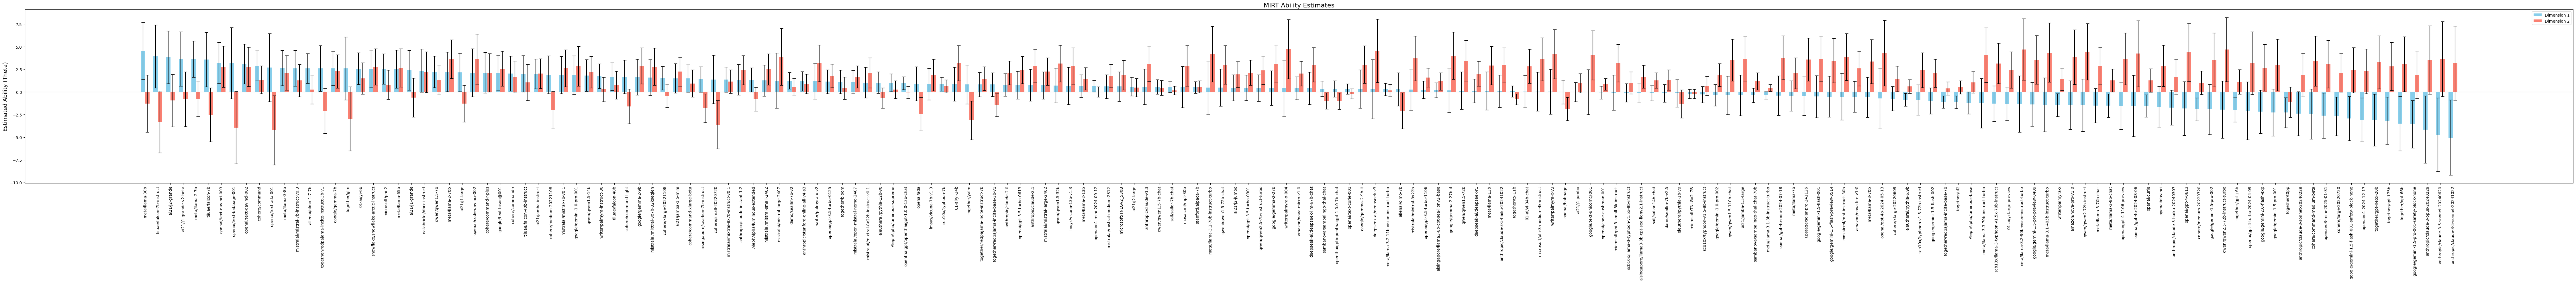

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = theta_df.sort_values('ability_dim1', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['ability_dim1']
ability2 = df_sorted['ability_dim2']
# Calculate the 95% confidence interval size (1.96 * SE)
ci1 = df_sorted['se_dim1']
ci2 = df_sorted['se_dim2']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Dimension 1', 
                yerr=ci1, capsize=4, color='skyblue')

rects2 = ax.bar(x + width/2, ability2, width, label='Dimension 2', 
                yerr=ci2, capsize=4, color='salmon')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('MIRT Ability Estimates', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_k{k}.pdf', bbox_inches='tight')

plt.show()